# Phase 3: Model Building
## Credit Scoring - Give Me Some Credit

**Author**: QuangMinh  
**Course**: MLE501 - AI & Machine Learning  
**Date**: 2026-03-11

---

## Muc tieu

Train 5 models ML voi **default parameters** va danh gia nhanh tren validation set:

| # | Model | Data | Xu ly imbalance |
|---|-------|------|----------------|
| 1 | Logistic Regression (baseline) | Scaled | class_weight='balanced' |
| 2 | LinearSVC | Scaled | class_weight='balanced' |
| 3 | Random Forest | Unscaled | class_weight='balanced' |
| 4 | XGBoost | Unscaled | scale_pos_weight=13.96 |
| 5 | LightGBM | Unscaled | is_unbalance=True |

**Metrics**: AUC-ROC, Recall, F1, Precision (khong dung Accuracy lam metric chinh)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics
from sklearn.metrics import (
    roc_auc_score, recall_score, f1_score, precision_score,
    classification_report, confusion_matrix, roc_curve, 
    precision_recall_curve, average_precision_score
)

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

from datetime import datetime
print(f"Phase 3 started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("Libraries imported successfully!")

Phase 3 started at: 2026-03-11 17:36:56
Libraries imported successfully!


## 2. Load Processed Data

In [2]:
print("="*80)
print("LOADING PROCESSED DATA")
print("="*80)

data_dir = '../data/processed/'

# Scaled data (for LR, SVM)
X_train_scaled = pd.read_csv(data_dir + 'X_train_scaled.csv')
X_val_scaled = pd.read_csv(data_dir + 'X_val_scaled.csv')

# Unscaled data (for RF, XGBoost, LightGBM)
X_train = pd.read_csv(data_dir + 'X_train.csv')
X_val = pd.read_csv(data_dir + 'X_val.csv')

# Target
y_train = pd.read_csv(data_dir + 'y_train.csv').squeeze()
y_val = pd.read_csv(data_dir + 'y_val.csv').squeeze()

# Calculate imbalance ratio for XGBoost
imbalance_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

print(f"\nScaled data:   X_train={X_train_scaled.shape}, X_val={X_val_scaled.shape}")
print(f"Unscaled data: X_train={X_train.shape}, X_val={X_val.shape}")
print(f"Target:        y_train={y_train.shape}, y_val={y_val.shape}")
print(f"\nClass distribution (training):")
print(f"  Good (0): {(y_train==0).sum():,} ({(y_train==0).mean()*100:.2f}%)")
print(f"  Bad  (1): {(y_train==1).sum():,} ({(y_train==1).mean()*100:.2f}%)")
print(f"  Imbalance ratio: {imbalance_ratio:.2f}:1")
print(f"  Features: {X_train.shape[1]}")

LOADING PROCESSED DATA

Scaled data:   X_train=(120000, 17), X_val=(30000, 17)
Unscaled data: X_train=(120000, 17), X_val=(30000, 17)
Target:        y_train=(120000,), y_val=(30000,)

Class distribution (training):
  Good (0): 111,979 (93.32%)
  Bad  (1): 8,021 (6.68%)
  Imbalance ratio: 13.96:1
  Features: 17


## 3. Helper Functions

In [3]:
def train_and_evaluate(model, model_name, X_tr, X_va, y_tr, y_va, use_decision_function=False):
    """
    Train model, predict on validation, return metrics dict.
    """
    print(f"\n{'='*80}")
    print(f"TRAINING: {model_name}")
    print(f"{'='*80}")
    
    # Train
    start_time = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start_time
    print(f"Training time: {train_time:.2f}s")
    
    # Predict
    y_pred = model.predict(X_va)
    
    # Predict probabilities for AUC-ROC
    if use_decision_function:
        y_prob = model.decision_function(X_va)
    elif hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_va)[:, 1]
    else:
        y_prob = model.decision_function(X_va)
    
    # Metrics
    auc = roc_auc_score(y_va, y_prob)
    recall = recall_score(y_va, y_pred)
    f1 = f1_score(y_va, y_pred)
    precision = precision_score(y_va, y_pred)
    
    print(f"\nValidation Results:")
    print(f"  AUC-ROC:   {auc:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    
    # Classification Report
    print(f"\nClassification Report:")
    print(classification_report(y_va, y_pred, target_names=['Good (0)', 'Bad (1)']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_va, y_pred)
    print(f"Confusion Matrix:")
    print(f"  TN={cm[0,0]:,}  FP={cm[0,1]:,}")
    print(f"  FN={cm[1,0]:,}  TP={cm[1,1]:,}")
    
    return {
        'Model': model_name,
        'AUC-ROC': auc,
        'Recall': recall,
        'F1-Score': f1,
        'Precision': precision,
        'Train_Time(s)': round(train_time, 2),
        'y_pred': y_pred,
        'y_prob': y_prob,
        'confusion_matrix': cm,
        'trained_model': model
    }

# Store all results
results = {}
print("Helper functions defined.")

Helper functions defined.


## 4. Model Training

### 4.1 Logistic Regression (Baseline)
- **Data**: Scaled
- **Imbalance**: class_weight='balanced'
- **Default params**: C=1.0, max_iter=1000

In [4]:
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=2
)

results['LR'] = train_and_evaluate(
    lr_model, 'Logistic Regression',
    X_train_scaled, X_val_scaled, y_train, y_val
)


TRAINING: Logistic Regression
Training time: 1.57s

Validation Results:
  AUC-ROC:   0.8610
  Recall:    0.7616
  F1-Score:  0.3356
  Precision: 0.2152

Classification Report:
              precision    recall  f1-score   support

    Good (0)       0.98      0.80      0.88     27995
     Bad (1)       0.22      0.76      0.34      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.78      0.61     30000
weighted avg       0.93      0.80      0.84     30000

Confusion Matrix:
  TN=22,426  FP=5,569
  FN=478  TP=1,527


### 4.2 LinearSVC
- **Data**: Scaled
- **Imbalance**: class_weight='balanced'
- **Note**: LinearSVC khong co predict_proba → wrap voi CalibratedClassifierCV de tinh AUC-ROC

In [5]:
# LinearSVC doesn't have predict_proba, wrap with CalibratedClassifierCV
base_svc = LinearSVC(
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)

# CalibratedClassifierCV adds predict_proba via Platt scaling
svc_model = CalibratedClassifierCV(base_svc, cv=3)

results['SVM'] = train_and_evaluate(
    svc_model, 'LinearSVC',
    X_train_scaled, X_val_scaled, y_train, y_val
)


TRAINING: LinearSVC
Training time: 0.39s

Validation Results:
  AUC-ROC:   0.8574
  Recall:    0.0658
  F1-Score:  0.1182
  Precision: 0.5789

Classification Report:
              precision    recall  f1-score   support

    Good (0)       0.94      1.00      0.97     27995
     Bad (1)       0.58      0.07      0.12      2005

    accuracy                           0.93     30000
   macro avg       0.76      0.53      0.54     30000
weighted avg       0.91      0.93      0.91     30000

Confusion Matrix:
  TN=27,899  FP=96
  FN=1,873  TP=132


### 4.3 Random Forest
- **Data**: Unscaled
- **Imbalance**: class_weight='balanced'
- **Default params**: n_estimators=100, max_depth=None

In [6]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

results['RF'] = train_and_evaluate(
    rf_model, 'Random Forest',
    X_train, X_val, y_train, y_val
)


TRAINING: Random Forest
Training time: 1.55s

Validation Results:
  AUC-ROC:   0.8335
  Recall:    0.1671
  F1-Score:  0.2566
  Precision: 0.5528

Classification Report:
              precision    recall  f1-score   support

    Good (0)       0.94      0.99      0.97     27995
     Bad (1)       0.55      0.17      0.26      2005

    accuracy                           0.94     30000
   macro avg       0.75      0.58      0.61     30000
weighted avg       0.92      0.94      0.92     30000

Confusion Matrix:
  TN=27,724  FP=271
  FN=1,670  TP=335


### 4.4 XGBoost
- **Data**: Unscaled
- **Imbalance**: scale_pos_weight = imbalance_ratio (~13.96)
- **Default params**: n_estimators=100, max_depth=6, learning_rate=0.3

In [7]:
xgb_model = XGBClassifier(
    scale_pos_weight=imbalance_ratio,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

results['XGB'] = train_and_evaluate(
    xgb_model, 'XGBoost',
    X_train, X_val, y_train, y_val
)


TRAINING: XGBoost
Training time: 0.19s

Validation Results:
  AUC-ROC:   0.8506
  Recall:    0.7042
  F1-Score:  0.3534
  Precision: 0.2359

Classification Report:
              precision    recall  f1-score   support

    Good (0)       0.98      0.84      0.90     27995
     Bad (1)       0.24      0.70      0.35      2005

    accuracy                           0.83     30000
   macro avg       0.61      0.77      0.63     30000
weighted avg       0.93      0.83      0.86     30000

Confusion Matrix:
  TN=23,422  FP=4,573
  FN=593  TP=1,412


### 4.5 LightGBM
- **Data**: Unscaled
- **Imbalance**: is_unbalance=True
- **Default params**: n_estimators=100, num_leaves=31, learning_rate=0.1

In [8]:
lgbm_model = LGBMClassifier(
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

results['LGBM'] = train_and_evaluate(
    lgbm_model, 'LightGBM',
    X_train, X_val, y_train, y_val
)


TRAINING: LightGBM
Training time: 0.26s

Validation Results:
  AUC-ROC:   0.8672
  Recall:    0.7711
  F1-Score:  0.3428
  Precision: 0.2204

Classification Report:
              precision    recall  f1-score   support

    Good (0)       0.98      0.80      0.88     27995
     Bad (1)       0.22      0.77      0.34      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.79      0.61     30000
weighted avg       0.93      0.80      0.85     30000

Confusion Matrix:
  TN=22,526  FP=5,469
  FN=459  TP=1,546


## 5. So sanh 5 Models

### 5.1 Bang ket qua tong hop

In [9]:
print("="*80)
print("MODEL COMPARISON - VALIDATION SET")
print("="*80)

comparison_df = pd.DataFrame([
    {
        'Model': results[k]['Model'],
        'AUC-ROC': results[k]['AUC-ROC'],
        'Recall': results[k]['Recall'],
        'F1-Score': results[k]['F1-Score'],
        'Precision': results[k]['Precision'],
        'Train Time (s)': results[k]['Train_Time(s)']
    }
    for k in ['LR', 'SVM', 'RF', 'XGB', 'LGBM']
])

# Sort by AUC-ROC
comparison_df = comparison_df.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
comparison_df.index = comparison_df.index + 1  # 1-indexed ranking

print("\nRanking by AUC-ROC:\n")
display(comparison_df)

# Best model
best_model_name = comparison_df.iloc[0]['Model']
best_auc = comparison_df.iloc[0]['AUC-ROC']
print(f"\nBest model (by AUC-ROC): {best_model_name} ({best_auc:.4f})")

MODEL COMPARISON - VALIDATION SET

Ranking by AUC-ROC:



,Model,AUC-ROC,Recall,F1-Score,Precision,Train Time (s)
1,LightGBM,0.867187,0.771072,0.342794,0.220385,0.26
2,Logistic Regression,0.860985,0.761596,0.335568,0.215192,1.57
3,LinearSVC,0.857437,0.065835,0.118227,0.578947,0.39
4,XGBoost,0.850604,0.704239,0.353442,0.235923,0.19
5,Random Forest,0.833545,0.167082,0.256607,0.552805,1.55



Best model (by AUC-ROC): LightGBM (0.8672)


### 5.2 ROC Curves

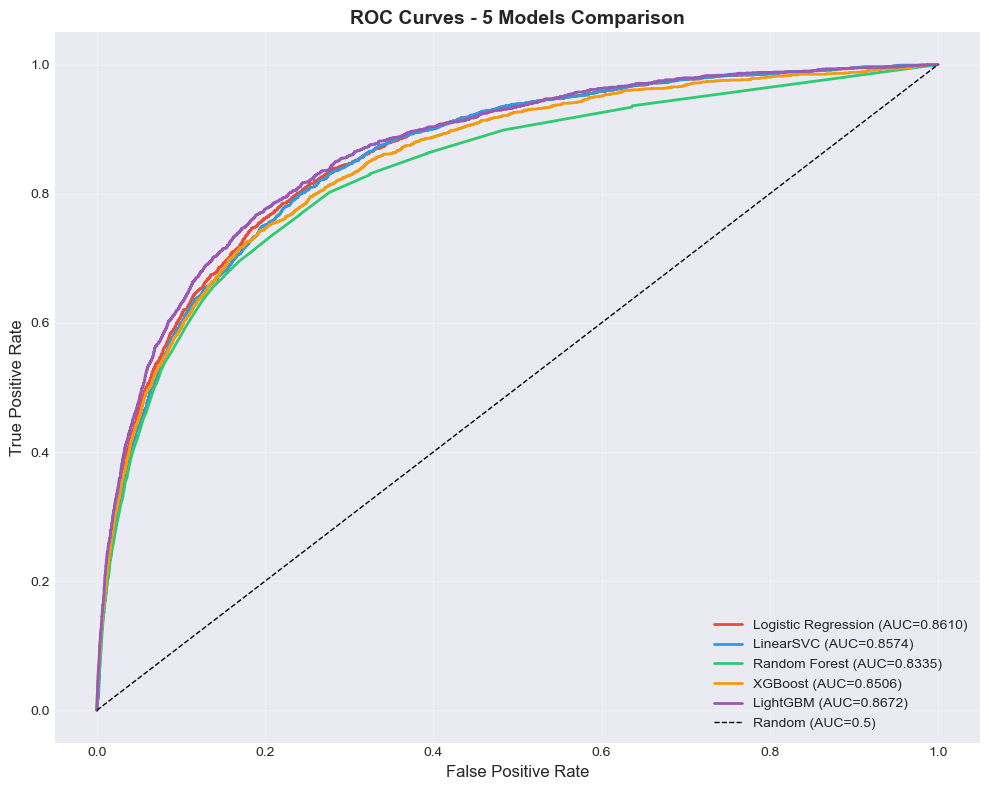

Saved: roc_curves_comparison.png


In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
model_keys = ['LR', 'SVM', 'RF', 'XGB', 'LGBM']

for i, key in enumerate(model_keys):
    fpr, tpr, _ = roc_curve(y_val, results[key]['y_prob'])
    auc_val = results[key]['AUC-ROC']
    ax.plot(fpr, tpr, color=colors[i], lw=2, 
            label=f"{results[key]['Model']} (AUC={auc_val:.4f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - 5 Models Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
report_dir = '../reports/[3] Ket qua Model Building/'
os.makedirs(report_dir, exist_ok=True)
plt.savefig(report_dir + 'roc_curves_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: roc_curves_comparison.png")

### 5.3 Confusion Matrices

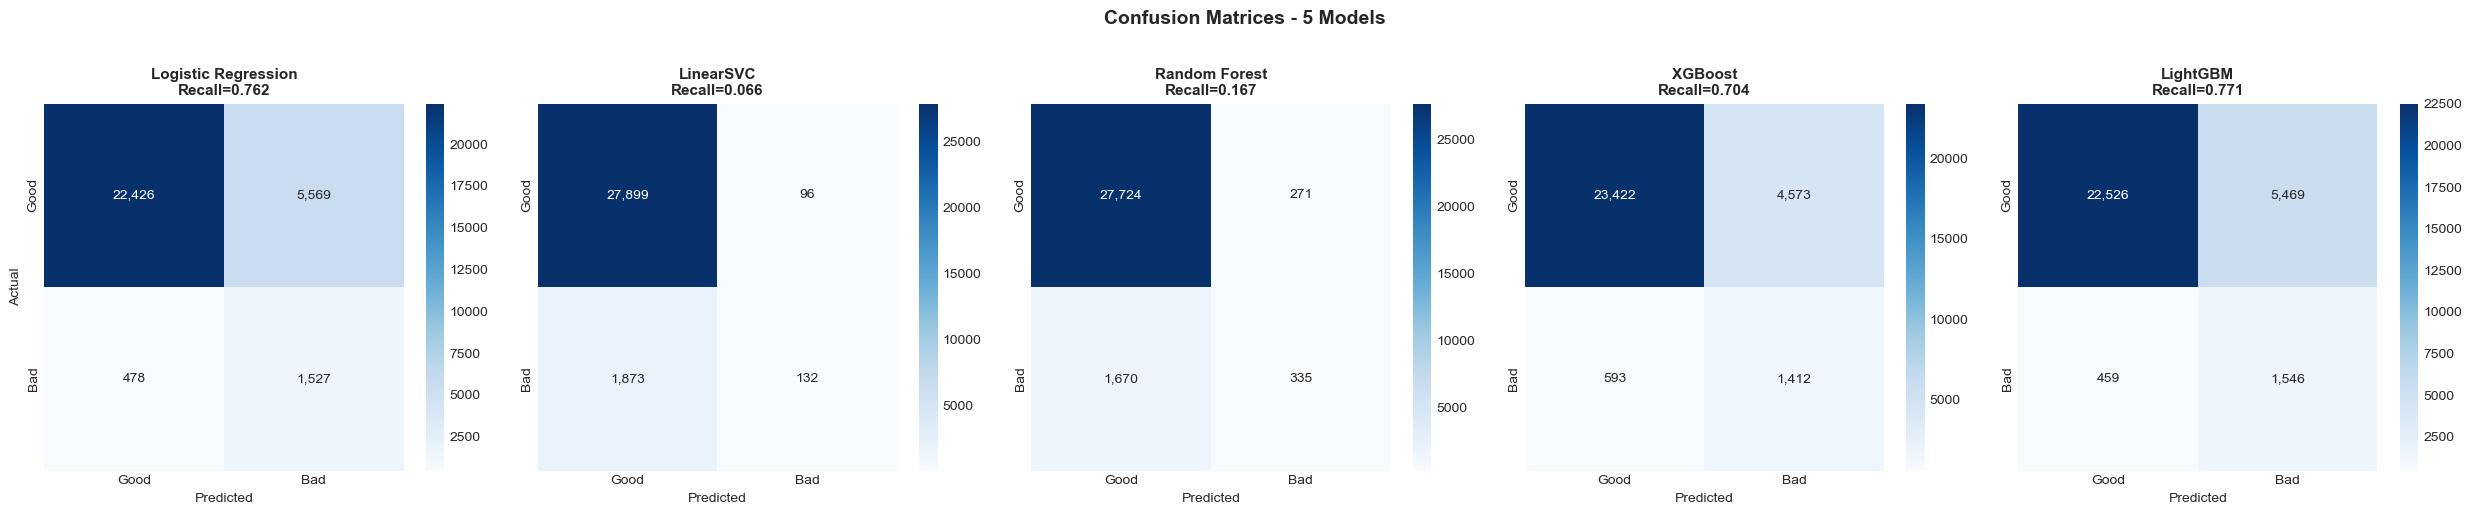

Saved: confusion_matrices.png


In [11]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, key in enumerate(model_keys):
    cm = results[key]['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=axes[i],
                xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
    axes[i].set_title(f"{results[key]['Model']}\nRecall={results[key]['Recall']:.3f}", 
                      fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Actual' if i == 0 else '')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices - 5 Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(report_dir + 'confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")

### 5.4 Metrics Comparison

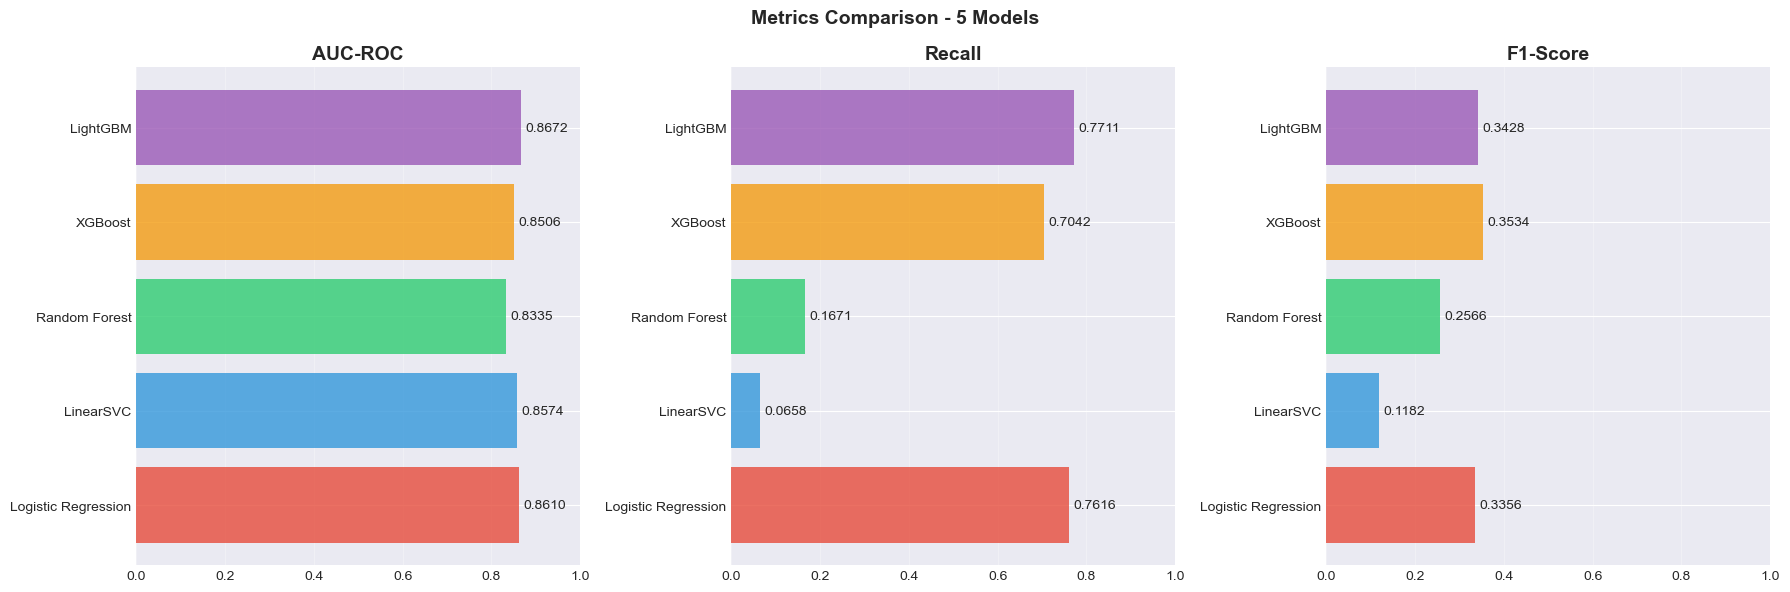

Saved: metrics_comparison.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['AUC-ROC', 'Recall', 'F1-Score']
model_names = [results[k]['Model'] for k in model_keys]

for i, metric in enumerate(metrics):
    values = [results[k][metric] for k in model_keys]
    bars = axes[i].barh(model_names, values, color=colors, alpha=0.8)
    axes[i].set_title(metric, fontsize=14, fontweight='bold')
    axes[i].set_xlim(0, 1)
    axes[i].grid(axis='x', alpha=0.3)
    
    # Add value labels
    for bar, val in zip(bars, values):
        axes[i].text(val + 0.01, bar.get_y() + bar.get_height()/2, 
                    f'{val:.4f}', va='center', fontsize=10)

plt.suptitle('Metrics Comparison - 5 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(report_dir + 'metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: metrics_comparison.png")

### 5.5 Feature Importance (Tree-based Models)

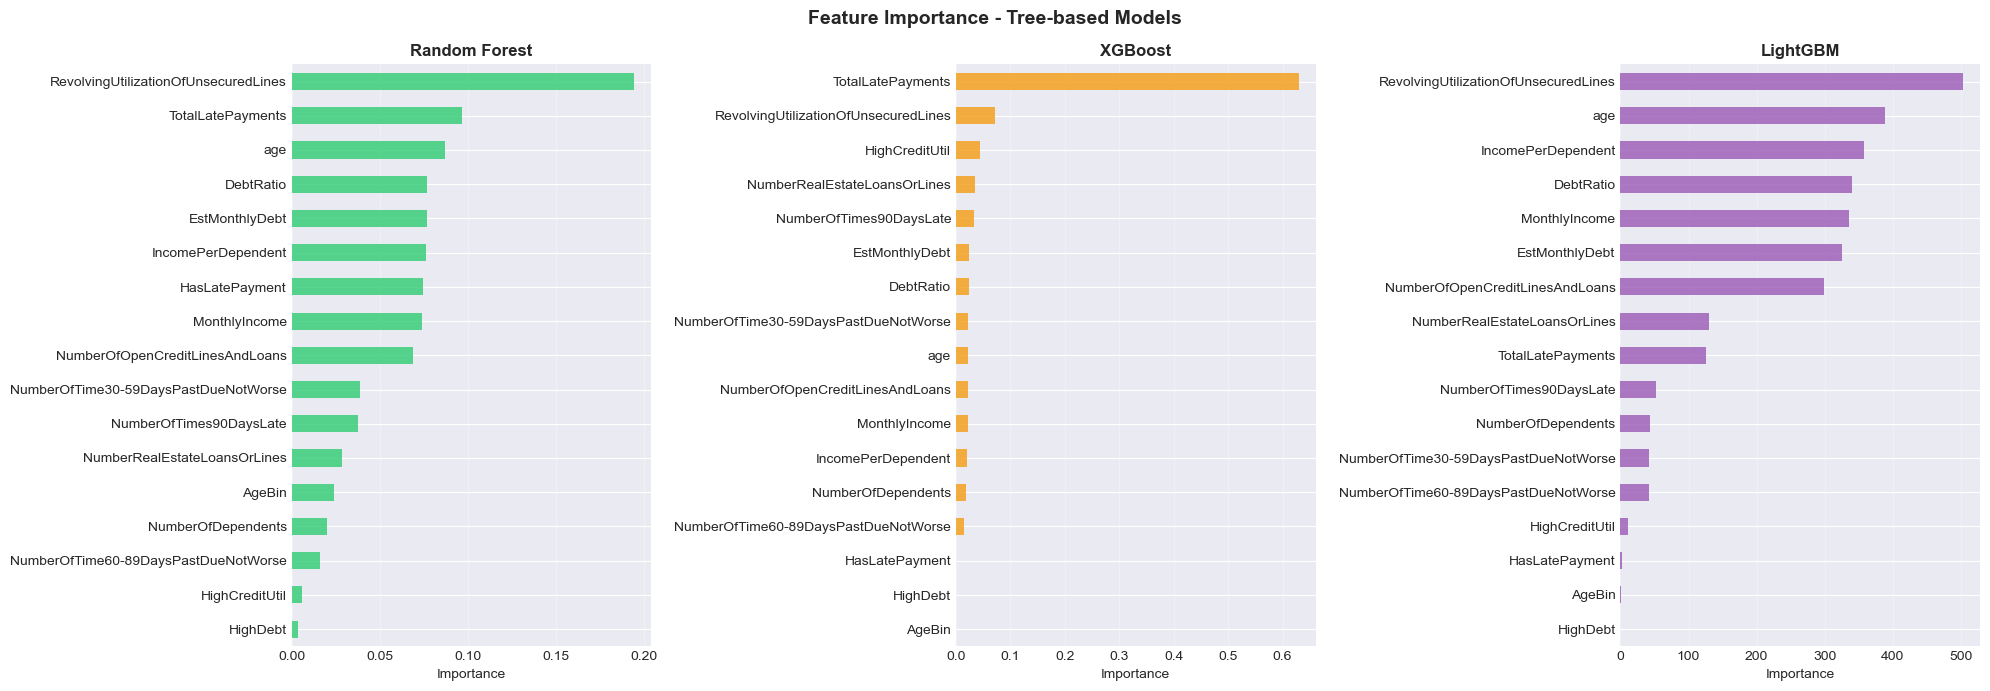

Saved: feature_importance.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

tree_models = {
    'Random Forest': results['RF']['trained_model'],
    'XGBoost': results['XGB']['trained_model'],
    'LightGBM': results['LGBM']['trained_model']
}

feature_names = X_train.columns.tolist()

for i, (name, model) in enumerate(tree_models.items()):
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)
    
    feat_imp.plot(kind='barh', ax=axes[i], color=colors[i+2], alpha=0.8)
    axes[i].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Importance')
    axes[i].grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance - Tree-based Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(report_dir + 'feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

## 6. Save Models & Results

In [14]:
print("="*80)
print("SAVING MODELS & RESULTS")
print("="*80)

# Save models
models_dir = '../models/'
os.makedirs(models_dir, exist_ok=True)

model_files = {
    'logistic_regression.pkl': results['LR']['trained_model'],
    'linear_svc.pkl': results['SVM']['trained_model'],
    'random_forest.pkl': results['RF']['trained_model'],
    'xgboost.pkl': results['XGB']['trained_model'],
    'lightgbm.pkl': results['LGBM']['trained_model']
}

print("\nSaving models...")
for fname, model in model_files.items():
    joblib.dump(model, models_dir + fname)
    print(f"  {fname}")

print(f"\nModels saved to: {models_dir}")

# Save comparison table
comparison_df.to_csv(report_dir + 'model_comparison.csv', index=False)
print(f"\nComparison table saved to: {report_dir}model_comparison.csv")

# Save detailed results
print("\n" + "="*80)
print("PHASE 3 COMPLETE")
print("="*80)
print(f"\nFiles saved:")
print(f"  Models: 5 files in models/")
print(f"  Reports:")
print(f"    - model_comparison.csv")
print(f"    - roc_curves_comparison.png")
print(f"    - confusion_matrices.png")
print(f"    - metrics_comparison.png")
print(f"    - feature_importance.png")

SAVING MODELS & RESULTS

Saving models...
  logistic_regression.pkl
  linear_svc.pkl
  random_forest.pkl
  xgboost.pkl
  lightgbm.pkl

Models saved to: ../models/

Comparison table saved to: ../reports/[3] Ket qua Model Building/model_comparison.csv

PHASE 3 COMPLETE

Files saved:
  Models: 5 files in models/
  Reports:
    - model_comparison.csv
    - roc_curves_comparison.png
    - confusion_matrices.png
    - metrics_comparison.png
    - feature_importance.png


## 7. Ket luan so bo

### Nhan xet (se cap nhat sau khi chay):
- Model nao cho AUC-ROC cao nhat?
- Model nao cho Recall cao nhat?
- Model nao can Hyperparameter Tuning o Phase 4?

### Next Steps:
- **Phase 4: Model Evaluation** — Phan tich chi tiet, Hyperparameter Tuning cho top models

In [ ]:
print(f"\nPhase 3 completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("\nReady for Phase 4: Model Evaluation!")


Phase 3 completed at: 2026-03-11 17:37:03

Ready for Phase 4: Model Evaluation!


Exception ignored in: <function ResourceTracker.__del__ at 0x106461bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105061bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
